In [1]:
#IMPORT FUNCTIONS ANS DEFINE START_DATE AND END_DATE
#ONLY CHANGE THIS CELL IF ADJUSTED FOR YEARS
import numpy as np
import pandas as pd
import os
from os import listdir
from os.path import isfile, join
import requests
import datetime
pd.set_option('display.max_rows', 50)

# Define start and end dates
start_date = datetime.datetime(2016, 1, 1, 0, 0)
end_date = datetime.datetime(2025, 12, 31, 23, 0)

#OUTPUT FILES WILL BE:
#Data_AQ_Vredepeel_{start_date.year}-{end_date.year}.csv
#Data_AQ_Zegveld_{start_date.year}-{end_date.year}.csv
#Data_AQ_Wekerom_{start_date.year}-{end_date.year}.csv

In [2]:
#FUNCTION DEFINITIONS (NO NEED TO CHANGE)

# Function to check if the file exists
def check_file_exists(url):
    try:
        response = requests.head(url)  # Use HEAD to check if the file exists without downloading
        return response.status_code == 200
    except requests.RequestException:
        return False

# Transform the data to the desired format
def transform_data(df):
    # Extract year, month, day, and hour from the 'begindatumtijd' column
    df['begindatumtijd'] = pd.to_datetime(df['begindatumtijd'])
    df['year'] = df['begindatumtijd'].dt.year
    df['month'] = df['begindatumtijd'].dt.month
    df['day'] = df['begindatumtijd'].dt.day
    df['hour'] = df['begindatumtijd'].dt.hour
    df['date-time'] = df['begindatumtijd'].dt.strftime('%Y-%m-%d %H:%M')
    
    # Reorder the columns to match the desired output
    df = df[['date-time', 'year', 'month', 'day', 'hour', 'NH3', 'NO', 'NO2']]
    
    return df

# Function to download and process data
def process_data(year, urls, skiprows):
    combined_data = pd.DataFrame()

    for component, url in urls.items():
        if not check_file_exists(url):
            print(f"File for {component} in {year} does not exist, skipping...")
            continue  # Skip this file if it doesn't exist
        
        # Download the file
        response = requests.get(url)
        file_path = f"{year}_{component}.csv"
        print("Processing file "+str(file_path))
        
        # Save the file locally
        with open(file_path, "wb") as file:
            file.write(response.content)
        
        # Load the data dynamically
        df = load_data(file_path)
        
        # Select only the necessary columns
        df = df[["meetlocatie_id", "begindatumtijd", "waarde"]]
        
        # Rename the 'waarde' column to include the component name (e.g., 'waarde_NO')
        df = df.rename(columns={"waarde": f"{component}"})
        
        # Merge this data with the combined_data DataFrame (based on meetlocatie_id and begindatumtijd)
        if combined_data.empty:
            combined_data = df
        else:
            combined_data = pd.merge(combined_data, df, on=["meetlocatie_id", "begindatumtijd"], how="outer")
        
        # Remove the file after processing
        try:
            os.remove(file_path)
            print(f"Removed temporary file {file_path}")
        except PermissionError:
            print(f"PermissionError: Unable to delete {file_path}, retrying...")
            time.sleep(2)  # Wait for a moment before retrying
            try:
                os.remove(file_path)
                print(f"Removed temporary file {file_path}")
            except Exception as e:
                print(f"Failed to remove {file_path}: {e}")

    return combined_data

# Create a function to fill missing times with NaN
def fill_missing_times(df, start_date, end_date):
    # Create a complete time range from start_date to end_date with a frequency of 1 hour
    complete_time_range = pd.date_range(start=start_date, end=end_date, freq='H')
    
    # Create a DataFrame with the complete time range as 'date-time'
    complete_df = pd.DataFrame({'date-time': complete_time_range})
    
    # Ensure both 'date-time' columns are of datetime type
    complete_df['date-time'] = pd.to_datetime(complete_df['date-time'])
    df['date-time'] = pd.to_datetime(df['date-time'])
    
    # Merge the complete DataFrame with the existing data to ensure all times are included
    df = pd.merge(complete_df, df, on='date-time', how='left')
    
    # Reorder the columns and return the result
    df['year'] = df['date-time'].dt.year
    df['month'] = df['date-time'].dt.month
    df['day'] = df['date-time'].dt.day
    df['hour'] = df['date-time'].dt.hour
    df = df[['date-time', 'year', 'month', 'day', 'hour', 'NH3', 'NO', 'NO2']]
    
    return df

def get_skiprows(file_path):
    # Open the file and read line by line
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    # Find the line number where the header starts with 'meetreeks_id'
    for i, line in enumerate(lines):
        if line.startswith('meetreeks_id'):
            return i  # Return the index of the header row
    
    # If no header is found, return None or raise an error
    raise ValueError("Header not found in the file")

def load_data(file_path):
    # Get the number of rows to skip
    skiprows = get_skiprows(file_path)
    
    # Load the CSV file into pandas with dynamic skiprows
    df = pd.read_csv(file_path, skiprows=skiprows, delimiter=";")  # Adjust delimiter if necessary
    return df


In [3]:
#ACTUAL CODE (NO NEED TO CHANGE)

df_all = pd.DataFrame()
df_vredepeel_list = []
df_zegveld_list = []
df_wekerom_list = []

# Loop over each year from start_date to end_date
current_date = start_date
while current_date <= end_date:
    year = current_date.year
    print("Processing year "+str(year))
    
    # Define URLs for NO, NO2, and NH3
    urls = {
        'NO': f"https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/{year}/{year}_NO.csv",
        'NO2': f"https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/{year}/{year}_NO2.csv",
        'NH3': f"https://data.rivm.nl/data/luchtmeetnet/Vastgesteld-jaar/{year}/{year}_NH3.csv"
    }

    # Check if the file exists in 'vastgesteld-jaar', otherwise check 'voorlopig-jaar'
    for component, url in urls.items():
        if not check_file_exists(url):
            print(f"File for {component} in {year} not found in 'vastgesteld-jaar', checking 'voorlopig-jaar'...")
            urls[component] = urls[component].replace(f"Vastgesteld-jaar/{year}/", "Voorlopig-jaar/")
        
    # Process data
    combined_data = process_data(year, urls, 0)
    
    # If there is data for this year, filter and process data for each location
    if not combined_data.empty:
        df_vredepeel = combined_data[combined_data["meetlocatie_id"] == "NL10131"].drop(columns=["meetlocatie_id"])
        df_zegveld = combined_data[combined_data["meetlocatie_id"] == "NL10633"].drop(columns=["meetlocatie_id"])
        df_wekerom = combined_data[combined_data["meetlocatie_id"] == "NL10738"].drop(columns=["meetlocatie_id"])
        
        # Append each year's data to the respective lists
        df_vredepeel_list.append(df_vredepeel)
        df_zegveld_list.append(df_zegveld)
        df_wekerom_list.append(df_wekerom)

    # Move to the next year
    current_date = current_date.replace(year=year + 1)
#ENDOFLOOP

# Concatenate all dataframes for each location into separate DataFrames
df_vredepeel_final = pd.concat(df_vredepeel_list, ignore_index=True)
df_zegveld_final = pd.concat(df_zegveld_list, ignore_index=True)
df_wekerom_final = pd.concat(df_wekerom_list, ignore_index=True)

# Transform data structure
df_vredepeel_transformed = transform_data(df_vredepeel_final)
df_zegveld_transformed = transform_data(df_zegveld_final)
df_wekerom_transformed = transform_data(df_wekerom_final)

#Fill missing values with NAN
df_vredepeel_filled = fill_missing_times(df_vredepeel_transformed, start_date, end_date)
df_zegveld_filled = fill_missing_times(df_zegveld_transformed, start_date, end_date)
df_wekerom_filled = fill_missing_times(df_wekerom_transformed, start_date, end_date)

# Save to .csv
df_vredepeel_filled.to_csv(f"Data_AQ_Vredepeel_{start_date.year}-{end_date.year}.csv", index=False, sep=";")
df_zegveld_filled.to_csv(f"Data_AQ_Zegveld_{start_date.year}-{end_date.year}.csv", index=False, sep=";")
df_wekerom_filled.to_csv(f"Data_AQ_Wekerom_{start_date.year}-{end_date.year}.csv", index=False, sep=";")

print("Vredepeel Data:")
print(df_vredepeel_filled)

print("Zegveld Data:")
print(df_zegveld_filled)

print("Wekerom Data:")
print(df_wekerom_filled)


Processing year 2016
Processing file 2016_NO.csv
Removed temporary file 2016_NO.csv
Processing file 2016_NO2.csv
Removed temporary file 2016_NO2.csv
Processing file 2016_NH3.csv
Removed temporary file 2016_NH3.csv
Processing year 2017
Processing file 2017_NO.csv
Removed temporary file 2017_NO.csv
Processing file 2017_NO2.csv
Removed temporary file 2017_NO2.csv
Processing file 2017_NH3.csv
Removed temporary file 2017_NH3.csv
Processing year 2018
Processing file 2018_NO.csv
Removed temporary file 2018_NO.csv
Processing file 2018_NO2.csv
Removed temporary file 2018_NO2.csv
Processing file 2018_NH3.csv
Removed temporary file 2018_NH3.csv
Processing year 2019
Processing file 2019_NO.csv
Removed temporary file 2019_NO.csv
Processing file 2019_NO2.csv
Removed temporary file 2019_NO2.csv
Processing file 2019_NH3.csv
Removed temporary file 2019_NH3.csv
Processing year 2020
Processing file 2020_NO.csv
Removed temporary file 2020_NO.csv
Processing file 2020_NO2.csv
Removed temporary file 2020_NO2

C:\Users\barte035\AppData\Local\Temp\ipykernel_29156\3676137268.py:116: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, skiprows=skiprows, delimiter=";")  # Adjust delimiter if necessary


Removed temporary file 2024_NH3.csv
Processing year 2025
Processing file 2025_NO.csv
Removed temporary file 2025_NO.csv
Processing file 2025_NO2.csv
Removed temporary file 2025_NO2.csv
Processing file 2025_NH3.csv


C:\Users\barte035\AppData\Local\Temp\ipykernel_29156\3676137268.py:116: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, skiprows=skiprows, delimiter=";")  # Adjust delimiter if necessary


Removed temporary file 2025_NH3.csv


C:\Users\barte035\AppData\Local\Temp\ipykernel_29156\3676137268.py:77: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  complete_time_range = pd.date_range(start=start_date, end=end_date, freq='H')
C:\Users\barte035\AppData\Local\Temp\ipykernel_29156\3676137268.py:84: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date-time'] = pd.to_datetime(df['date-time'])
C:\Users\barte035\AppData\Local\Temp\ipykernel_29156\3676137268.py:77: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  complete_time_range = pd.date_range(start=start_date, end=end_date, freq='H')
C:\Users\barte035\AppData\Local\Temp\ipykernel_29156\3676137268.py:84: SettingWithCopyWarni

Vredepeel Data:
                date-time  year  month  day  hour    NH3    NO    NO2
0     2016-01-01 00:00:00  2016      1    1     0  6.010  0.30   8.86
1     2016-01-01 01:00:00  2016      1    1     1  5.724  0.16   7.86
2     2016-01-01 02:00:00  2016      1    1     2  8.609 -0.10   9.34
3     2016-01-01 03:00:00  2016      1    1     3  7.604  0.12   7.29
4     2016-01-01 04:00:00  2016      1    1     4  6.910  0.12   4.53
...                   ...   ...    ...  ...   ...    ...   ...    ...
87667 2025-12-31 19:00:00  2025     12   31    19  7.557  0.08   5.29
87668 2025-12-31 20:00:00  2025     12   31    20  6.612 -0.08   4.81
87669 2025-12-31 21:00:00  2025     12   31    21  6.028  0.47  13.68
87670 2025-12-31 22:00:00  2025     12   31    22  3.934  0.07  12.68
87671 2025-12-31 23:00:00  2025     12   31    23  4.291  0.55  17.62

[87672 rows x 8 columns]
Zegveld Data:
                date-time  year  month  day  hour    NH3    NO    NO2
0     2016-01-01 00:00:00  2016   

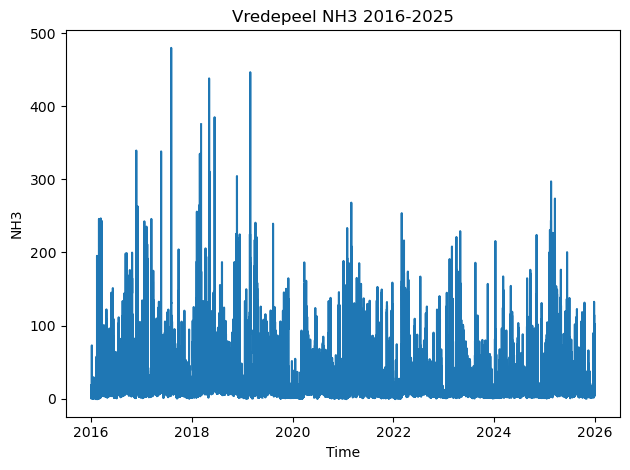

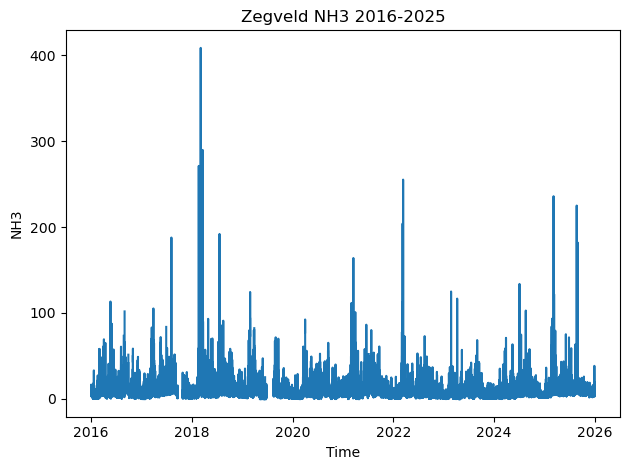

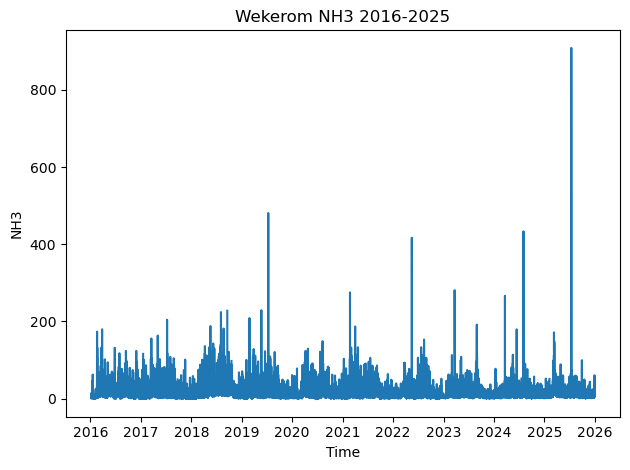

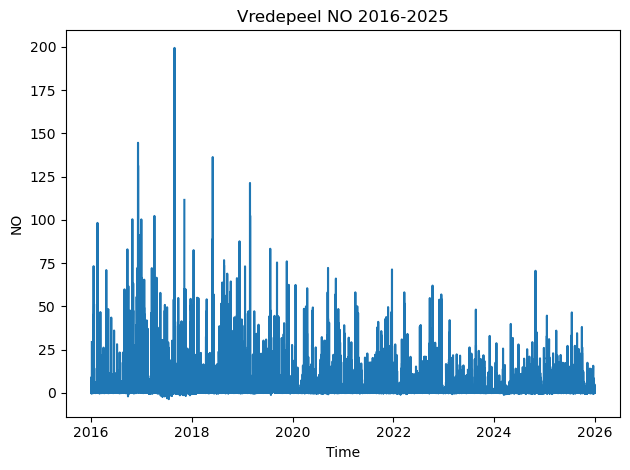

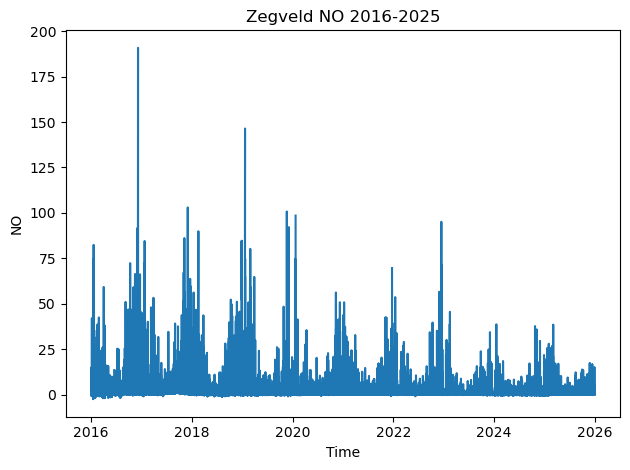

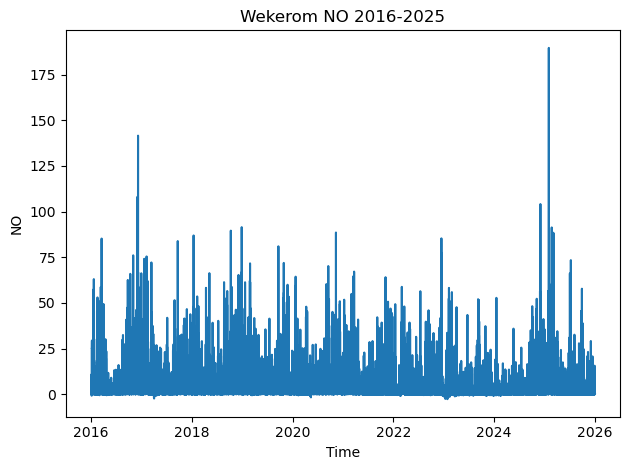

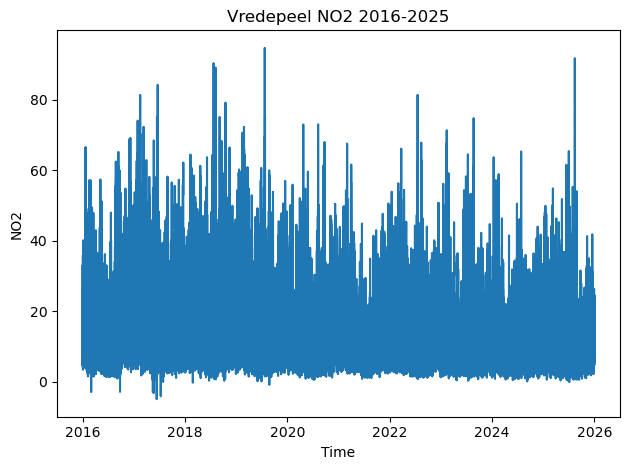

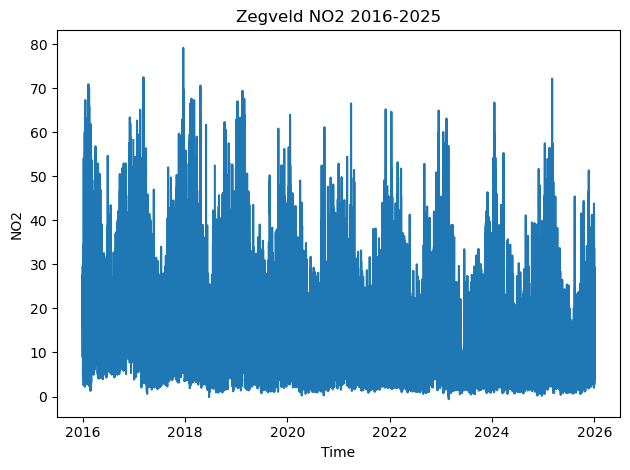

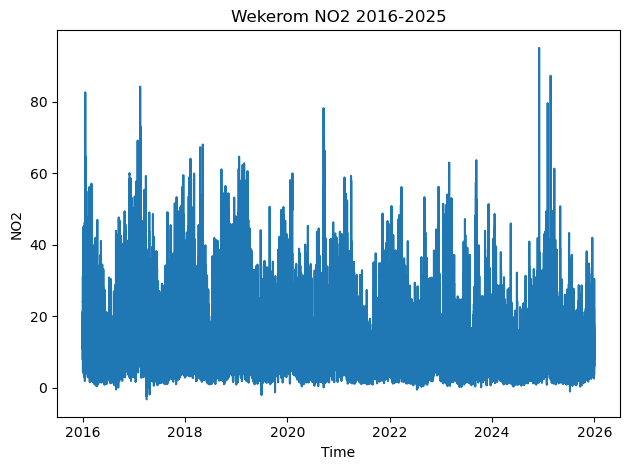

In [8]:
import matplotlib.pyplot as plt

vp = pd.read_csv(f"Data_AQ_Vredepeel_{start_date.year}-{end_date.year}.csv", sep=";")
zv = pd.read_csv(f"Data_AQ_Zegveld_{start_date.year}-{end_date.year}.csv", sep=";")
wk = pd.read_csv(f"Data_AQ_Wekerom_{start_date.year}-{end_date.year}.csv", sep=";")

vp['date-time'] = pd.to_datetime(vp['date-time'])
zv['date-time'] = pd.to_datetime(zv['date-time'])
wk['date-time'] = pd.to_datetime(wk['date-time'])
start_year = vp['year'].min()
end_year = vp['year'].max()

variables = ['NH3', 'NO', 'NO2']

for var in variables:
    plt.figure()
    plt.plot(vp['date-time'], vp[var])
    plt.title(f"Vredepeel {var} {start_year}-{end_year}")
    plt.xlabel("Time")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(zv['date-time'], zv[var])
    plt.title(f"Zegveld {var} {start_year}-{end_year}")
    plt.xlabel("Time")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(wk['date-time'], wk[var])
    plt.title(f"Wekerom {var} {start_year}-{end_year}")
    plt.xlabel("Time")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()